<a href="https://colab.research.google.com/github/swapna-design/FUTURE_ML_02/blob/main/Support_Ticket_Classification_System(FI).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
plt.rcParams["figure.dpi"] = 110

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [2]:
random.seed(42)
np.random.seed(42)

categories = {
    "Billing": [
        "I was charged twice for my {plan} subscription this month",
        "My invoice shows an incorrect amount for {plan}",
        "I need a refund for the {plan} plan I cancelled last week",
        "Why did my card get billed for {plan} when I already cancelled",
        "Can you explain the extra charge on my last {plan} invoice",
        "I want to update my payment method for {plan}",
        "The discount code did not apply to my {plan} purchase",
    ],
    "Technical Issue": [
        "The app keeps crashing every time I open the {feature} section",
        "I am getting an error message when I try to use {feature}",
        "{feature} is not loading at all on my device",
        "The website is extremely slow when I access {feature}",
        "I lost all my data after the {feature} update",
        "Getting a 500 server error on the {feature} page",
        "The {feature} button does nothing when I click it",
    ],
    "Account Access": [
        "I cannot log into my account, it says password incorrect",
        "I am locked out of my account after too many login attempts",
        "The two factor authentication code never arrives",
        "I forgot my password and the reset link is not working",
        "My account got suspended and I do not know why",
        "Someone else may have accessed my account without permission",
        "I need to change the email linked to my account",
    ],
    "Product Inquiry": [
        "Does the {plan} plan include {feature} access",
        "What is the difference between {plan} and the free plan",
        "Can I use {feature} on multiple devices",
        "Is there a student discount available for {plan}",
        "How many users can I add under the {plan} plan",
        "Do you offer a trial for {feature} before upgrading",
        "What integrations are supported with {feature}",
    ],
    "Feature Request": [
        "It would be great if {feature} supported dark mode",
        "Please add an export option to {feature}",
        "Can you add keyboard shortcuts for {feature}",
        "I would love to see offline support for {feature}",
        "Requesting a bulk upload option in {feature}",
        "Please consider adding multi-language support to {feature}",
        "A calendar view for {feature} would be really useful",
    ],
}

plans = ["Basic", "Pro", "Premium", "Enterprise", "annual", "monthly"]
features = ["dashboard", "billing portal", "reporting", "mobile app", "chat support",
            "file upload", "analytics", "notifications", "search", "export tool"]

urgency_high = [
    "This is urgent, I need this fixed immediately.",
    "This is blocking my entire team from working, please help ASAP.",
    "I have a deadline today and this is critical.",
    "This has been broken for 3 days and no one has responded.",
    "This is a major issue affecting our production system.",
]
urgency_medium = [
    "Please look into this when you get a chance.",
    "This is affecting my work but I have a workaround for now.",
    "Would appreciate a fix in the next few days.",
    "Not blocking me completely but it's annoying.",
]
urgency_low = [
    "No rush, just wanted to flag this.",
    "This is a minor issue, whenever convenient.",
    "Just curious about this, not urgent at all.",
    "Low priority, just wanted to check.",
]

rows = []
for _ in range(1200):
    cat = random.choice(list(categories.keys()))
    template = random.choice(categories[cat])
    text = template.format(plan=random.choice(plans), feature=random.choice(features))

    if cat in ["Technical Issue", "Account Access"]:
        urgency_choice = random.choices(["high", "medium", "low"], weights=[0.5, 0.35, 0.15])[0]
    elif cat == "Billing":
        urgency_choice = random.choices(["high", "medium", "low"], weights=[0.3, 0.45, 0.25])[0]
    else:
        urgency_choice = random.choices(["high", "medium", "low"], weights=[0.1, 0.35, 0.55])[0]

    if urgency_choice == "high":
        text += " " + random.choice(urgency_high); priority = "High"
    elif urgency_choice == "medium":
        text += " " + random.choice(urgency_medium); priority = "Medium"
    else:
        text += " " + random.choice(urgency_low); priority = "Low"

    rows.append({"ticket_text": text, "category": cat, "priority": priority})

df = pd.DataFrame(rows)
df.to_csv("/content/sample_data/support_tickets.csv", index=False)
print(df.head())
print(df["category"].value_counts())
print(df["priority"].value_counts())

                                         ticket_text         category priority
0  I was charged twice for my monthly subscriptio...          Billing     High
1  I want to update my payment method for monthly...          Billing     High
2  I was charged twice for my Basic subscription ...          Billing     High
3  Can you explain the extra charge on my last Pr...          Billing   Medium
4  Can you add keyboard shortcuts for reporting J...  Feature Request      Low
category
Billing            254
Technical Issue    254
Product Inquiry    242
Account Access     230
Feature Request    220
Name: count, dtype: int64
priority
Medium    441
Low       386
High      373
Name: count, dtype: int64


In [3]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)          # remove punctuation/numbers
    tokens = word_tokenize(text)                    # tokenization
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOPWORDS and len(t) > 2]  # stopword removal + lemmatization
    return " ".join(tokens)

df = pd.read_csv("/content/sample_data/support_tickets.csv")
df["clean_text"] = df["ticket_text"].apply(clean_text)
df[["ticket_text", "clean_text"]].head()

,ticket_text,clean_text
0,I was charged twice for my monthly subscriptio...,charged twice monthly subscription month block...
1,I want to update my payment method for monthly...,want update payment method monthly broken day ...
2,I was charged twice for my Basic subscription ...,charged twice basic subscription month major i...
3,Can you explain the extra charge on my last Pr...,explain extra charge last pro invoice blocking...
4,Can you add keyboard shortcuts for reporting J...,add keyboard shortcut reporting curious urgent


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df["clean_text"]
y_cat = df["category"]

X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

cat_model = LogisticRegression(max_iter=1000)
cat_model.fit(X_train_tfidf, y_cat_train)
cat_pred = cat_model.predict(X_test_tfidf)

print("Category Accuracy:", accuracy_score(y_cat_test, cat_pred))
print(classification_report(y_cat_test, cat_pred))

Category Accuracy: 1.0
                 precision    recall  f1-score   support

 Account Access       1.00      1.00      1.00        46
        Billing       1.00      1.00      1.00        51
Feature Request       1.00      1.00      1.00        44
Product Inquiry       1.00      1.00      1.00        48
Technical Issue       1.00      1.00      1.00        51

       accuracy                           1.00       240
      macro avg       1.00      1.00      1.00       240
   weighted avg       1.00      1.00      1.00       240



In [5]:
y_pri = df["priority"]
X_train2, X_test2, y_pri_train, y_pri_test = train_test_split(
    X, y_pri, test_size=0.2, random_state=42, stratify=y_pri
)
X_train2_tfidf = tfidf.transform(X_train2)
X_test2_tfidf = tfidf.transform(X_test2)

pri_model = LogisticRegression(max_iter=1000)
pri_model.fit(X_train2_tfidf, y_pri_train)
pri_pred = pri_model.predict(X_test2_tfidf)

print("Priority Accuracy:", accuracy_score(y_pri_test, pri_pred))
print(classification_report(y_pri_test, pri_pred))

Priority Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        75
         Low       1.00      1.00      1.00        77
      Medium       1.00      1.00      1.00        88

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [7]:
def classify_ticket(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    category = cat_model.predict(vec)[0]
    priority = pri_model.predict(vec)[0]
    return category, priority

# Try it on a new, unseen ticket
sample = "My app crashes every time I open the dashboard and I have a client demo in an hour, please help urgently"
cat, pri = classify_ticket(sample)
print(f"Ticket: {sample}\nCategory: {cat} | Priority: {pri}")

Ticket: My app crashes every time I open the dashboard and I have a client demo in an hour, please help urgently
Category: Technical Issue | Priority: High


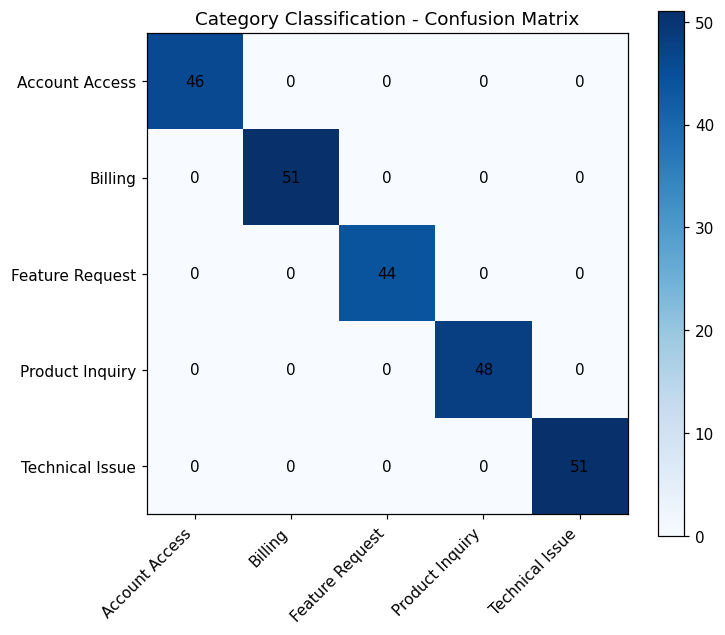

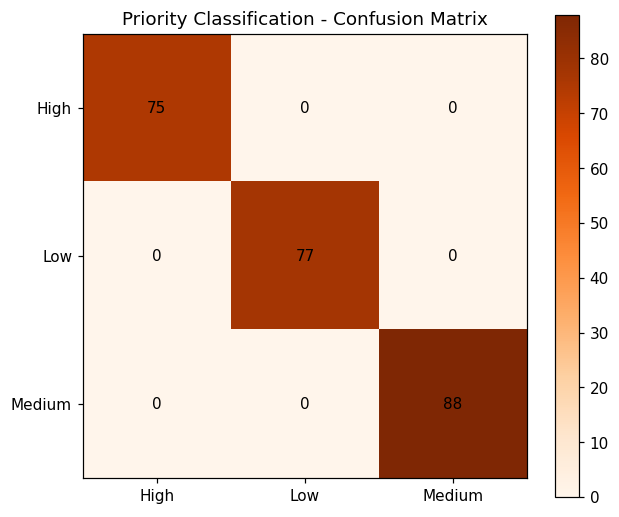

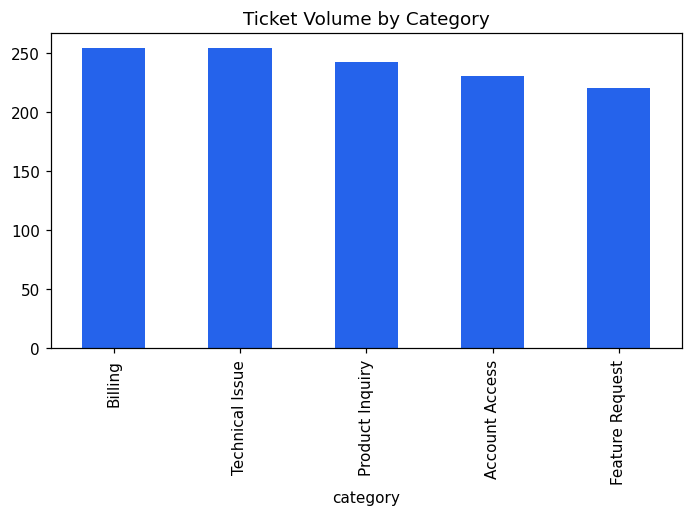

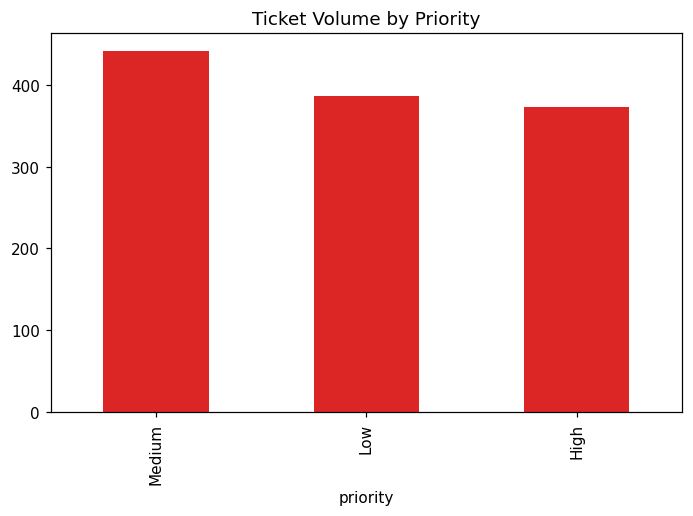

In [8]:
cm = confusion_matrix(y_cat_test, cat_pred, labels=cat_model.classes_)
plt.figure(figsize=(7,6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(cat_model.classes_)), cat_model.classes_, rotation=45, ha="right")
plt.yticks(range(len(cat_model.classes_)), cat_model.classes_)
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Category Classification - Confusion Matrix")
plt.colorbar(); plt.tight_layout(); plt.show()

cm2 = confusion_matrix(y_pri_test, pri_pred, labels=pri_model.classes_)
plt.figure(figsize=(6,5))
plt.imshow(cm2, cmap="Oranges")
plt.xticks(range(len(pri_model.classes_)), pri_model.classes_)
plt.yticks(range(len(pri_model.classes_)), pri_model.classes_)
for i in range(len(cm2)):
    for j in range(len(cm2)):
        plt.text(j, i, cm2[i, j], ha="center", va="center")
plt.title("Priority Classification - Confusion Matrix")
plt.colorbar(); plt.tight_layout(); plt.show()

df["category"].value_counts().plot(kind="bar", color="#2563eb", title="Ticket Volume by Category")
plt.tight_layout(); plt.show()

df["priority"].value_counts().plot(kind="bar", color="#dc2626", title="Ticket Volume by Priority")
plt.tight_layout(); plt.show()